In [10]:
import pandas as pd

def build_cycle_features(eocv_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build one row per (cell_id, age_step) with enriched SoH and degradation features
    from the EOCV result data.
    """
    df = eocv_df.copy()

    # sort by time within each cell
    df = df.sort_values(["cell_id", "timestamp_s"])

    # age_step index per cell: 0,1,2,...
    df["age_step"] = df.groupby("cell_id").cumcount()

    # capacity and SoH as given
    df["cap_abs_Ah"] = df["cap_aged_est_Ah"]
    df["soh"] = df["soh_cap"]

    # relative capacity vs first check-up
    df["cap_init_Ah"] = df.groupby("cell_id")["cap_abs_Ah"].transform("first")
    df["cap_rel"] = df["cap_abs_Ah"] / df["cap_init_Ah"]

    # temperature and SOC windows
    df["temp_delta_degC"] = df["t_end_degC"] - df["t_start_degC"]
    df["soc_window"] = df["soc_est_end"] - df["soc_est_start"]

    # SoH change vs previous age_step
    df["soh_prev"] = df.groupby("cell_id")["soh"].shift(1)
    df["d_soh"] = df["soh"] - df["soh_prev"]

    # capacity / energy increments as features
    # (already per-step, but include them explicitly)
    for col in [
        "delta_q_Ah",
        "delta_q_chg_Ah",
        "delta_q_dischg_Ah",
        "delta_e_Wh",
        "delta_e_chg_Wh",
        "delta_e_dischg_Wh",
    ]:
        if col in df.columns:
            df[col] = df[col]

    # select feature columns (target soh + enriched features)
    feature_cols = [
        "cell_id",
        "age_step",
        "timestamp_s",
        "soh",
        "cap_abs_Ah",
        "cap_rel",
        "d_soh",
        "age_type",
        "age_temp",
        "age_soc",
        "age_chg_rate",
        "age_dischg_rate",
        "age_profile",
        "cyc_duration_s",
        "num_cycles_op",
        "num_cycles_checkup",
        "coulomb_efficiency",
        "energy_efficiency",
        "soc_est_start",
        "soc_est_end",
        "soc_window",
        "t_start_degC",
        "t_end_degC",
        "temp_delta_degC",
        "delta_q_Ah",
        "delta_q_chg_Ah",
        "delta_q_dischg_Ah",
        "delta_e_Wh",
        "delta_e_chg_Wh",
        "delta_e_dischg_Wh",
    ]

    # keep only columns that actually exist (in case some delta_* are missing)
    feature_cols = [c for c in feature_cols if c in df.columns]

    feat = df[feature_cols].dropna(subset=["soh"])
    return feat

In [11]:
eocv_dir = Path("data") / "raw" / "results" / "cell_eocv2"
eocv_df = load_all_eocv(eocv_dir)
eocv_df.head(), eocv_df["cell_id"].nunique(), eocv_df.shape

(    timestamp_s timestamp_origin sd_block_id cyc_condition cyc_charged  \
 0  1665603148.0                1    69921792             0           0   
 1  1665603642.0                1    70050816             0           0   
 2  1665615385.0                1    73063936             2           1   
 3  1665626446.0                1    75906048             2           0   
 4  1665645948.0                1    80903680             0           1   
 
   age_type age_temp age_soc age_chg_rate age_dischg_rate  ...  \
 0        1        0      10          0.0             0.0  ...   
 1        1        0      10          0.0             0.0  ...   
 2        1        0      10          0.0             0.0  ...   
 3        1        0      10          0.0             0.0  ...   
 4        1        0      10          0.0             0.0  ...   
 
   total_e_chg_cyc_OT_Wh total_e_dischg_cyc_OT_Wh total_e_chg_other_RT_Wh  \
 0                   0.0                      0.0                     0.0

In [12]:
features = build_cycle_features(eocv_df)
features.head(), features["cell_id"].nunique(), features.shape

(           cell_id  age_step   timestamp_s        soh cap_abs_Ah   cap_rel  \
 2   P001_1_S01_C10         2  1665615385.0  98.238498   2.973577       1.0   
 3   P001_1_S01_C10         3  1665626446.0  97.849625   2.967744  0.998038   
 16  P001_1_S01_C10        16  1666221514.0  98.752719   2.981291  1.002594   
 17  P001_1_S01_C10        17  1666232539.0  97.470522   2.962058  0.996126   
 31  P001_1_S01_C10        31  1668020723.0  97.845078   2.967676  0.998016   
 
        d_soh age_type age_temp age_soc  ... soc_window t_start_degC  \
 2        NaN        1        0      10  ...    99.1211        25.51   
 3  -0.388873        1        0      10  ...   -99.1056         24.3   
 16       NaN        1        0      10  ...    99.1899        25.45   
 17 -1.282197        1        0      10  ...   -99.1283        25.44   
 31       NaN        1        0      10  ...    99.1925         25.9   
 
    t_end_degC temp_delta_degC delta_q_Ah delta_q_chg_Ah delta_q_dischg_Ah  \
 2        24

In [13]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ----- 1. Choose feature columns (now enriched) -----
feature_cols = [
    "age_step",
    "age_temp",
    "age_soc",
    "age_chg_rate",
    "age_dischg_rate",
    "cyc_duration_s",
    "num_cycles_op",
    "num_cycles_checkup",
    "coulomb_efficiency",
    "energy_efficiency",
    "cap_rel",
    "d_soh",
    "soc_window",
    "t_start_degC",
    "t_end_degC",
    "temp_delta_degC",
    "delta_q_Ah",
    "delta_q_chg_Ah",
    "delta_q_dischg_Ah",
    "delta_e_Wh",
    "delta_e_chg_Wh",
    "delta_e_dischg_Wh",
]

# keep only columns that exist (in case some delta_* are missing)
feature_cols = [c for c in feature_cols if c in features.columns]

# ----- 2. Ensure numeric dtypes -----
for col in feature_cols:
    features[col] = pd.to_numeric(features[col], errors="coerce")

# drop rows with NaNs in features or target
features_model = features.dropna(subset=feature_cols + ["soh"])

# ----- 3. Split by cell_id -----
cell_ids = features_model["cell_id"].astype(str).to_numpy()

train_cells, test_cells = train_test_split(
    cell_ids, test_size=0.2, random_state=42
)

train_df = features_model[features_model["cell_id"].isin(train_cells)]
test_df = features_model[features_model["cell_id"].isin(test_cells)]

X_train = train_df[feature_cols]
y_train = train_df["soh"]

X_test = test_df[feature_cols]
y_test = test_df["soh"]

# ----- 4. Train XGBoost -----
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model.fit(X_train, y_train)

# ----- 5. Evaluate -----
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mae, rmse

(0.4166092872619629, np.float64(0.545923713549313))

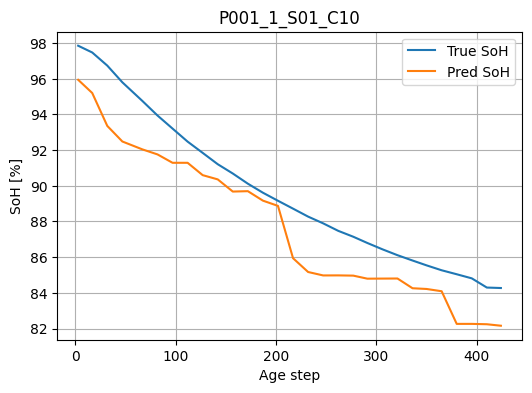

In [14]:
import matplotlib.pyplot as plt

test_cell = test_df["cell_id"].unique()[0]
mask = test_df["cell_id"] == test_cell

plt.figure(figsize=(6,4))
plt.plot(test_df.loc[mask, "age_step"], y_test[mask], label="True SoH")
plt.plot(test_df.loc[mask, "age_step"], y_pred[mask], label="Pred SoH")
plt.xlabel("Age step")
plt.ylabel("SoH [%]")
plt.title(test_cell)
plt.legend()
plt.grid(True)
plt.show()

In [15]:
from pathlib import Path
import pandas as pd

eis_dir = Path("data") / "raw" / "results" / "cell_eisv2"

list(eis_dir.iterdir())[:10]

[WindowsPath('data/raw/results/cell_eisv2/cell_eisv2_P000_0_S20_C00.csv'),
 WindowsPath('data/raw/results/cell_eisv2/cell_eisv2_P000_0_S20_C01.csv'),
 WindowsPath('data/raw/results/cell_eisv2/cell_eisv2_P000_0_S20_C02.csv'),
 WindowsPath('data/raw/results/cell_eisv2/cell_eisv2_P000_0_S20_C03.csv'),
 WindowsPath('data/raw/results/cell_eisv2/cell_eisv2_P000_0_S20_C04.csv'),
 WindowsPath('data/raw/results/cell_eisv2/cell_eisv2_P000_0_S20_C05.csv'),
 WindowsPath('data/raw/results/cell_eisv2/cell_eisv2_P000_0_S20_C06.csv'),
 WindowsPath('data/raw/results/cell_eisv2/cell_eisv2_P000_0_S20_C07.csv'),
 WindowsPath('data/raw/results/cell_eisv2/cell_eisv2_P000_0_S20_C08.csv'),
 WindowsPath('data/raw/results/cell_eisv2/cell_eisv2_P000_0_S20_C09.csv')]

In [16]:
from pathlib import Path
import pandas as pd

eis_dir = Path("data") / "raw" / "results" / "cell_eisv2"

example_eis_file = eis_dir / "cell_eisv2_P000_0_S20_C00.csv"
eis_df = pd.read_csv(example_eis_file, sep=";")

eis_df.head()

,timestamp_s,timestamp_origin,sd_block_id,cyc_charged,is_rt,soc_nom,valid,z_ref_init_mOhm,z_ref_now_mOhm,soh_imp,...,eis_duration_s,uptime_ticks,seq_nr,freq_Hz,z_amp_mOhm,z_ph_deg,z_amp_comp_mOhm,z_ph_comp_deg,z_re_comp_mOhm,z_im_comp_mOhm


In [17]:
eis_df.columns.tolist()


['timestamp_s',
 'timestamp_origin',
 'sd_block_id',
 'cyc_charged',
 'is_rt',
 'soc_nom',
 'valid',
 'z_ref_init_mOhm',
 'z_ref_now_mOhm',
 'soh_imp',
 'ocv_est_avg_V',
 't_avg_degC',
 'eis_duration_s',
 'uptime_ticks',
 'seq_nr',
 'freq_Hz',
 'z_amp_mOhm',
 'z_ph_deg',
 'z_amp_comp_mOhm',
 'z_ph_comp_deg',
 'z_re_comp_mOhm',
 'z_im_comp_mOhm']

In [22]:
import pandas as pd

def build_eis_features(eis_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate raw EIS spectra into one feature row per (cell_id, timestamp_s).
    """
    df = eis_df.copy()

    # ensure numeric where needed
    num_cols = [
        "z_ref_init_mOhm",
        "z_ref_now_mOhm",
        "soh_imp",
        "ocv_est_avg_V",
        "t_avg_degC",
        "eis_duration_s",
        "freq_Hz",
        "z_amp_mOhm",
        "z_ph_deg",
        "z_amp_comp_mOhm",
        "z_ph_comp_deg",
        "z_re_comp_mOhm",
        "z_im_comp_mOhm",
    ]
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # drop rows without frequency (corrupted spectra)
    df = df.dropna(subset=["freq_Hz"])

    rows = []
    # group by cell and timestamp
    for (cell_id, ts), g in df.groupby(["cell_id", "timestamp_s"]):
        g = g.sort_values("freq_Hz")

        low = g.iloc[0]
        high = g.iloc[-1]

        row = {
            "cell_id": cell_id,
            "timestamp_s": ts,

            # meta from first row
            "z_ref_init_mOhm": g["z_ref_init_mOhm"].iloc[0],
            "z_ref_now_mOhm": g["z_ref_now_mOhm"].iloc[0],
            "soh_imp": g["soh_imp"].iloc[0],
            "ocv_est_avg_V": g["ocv_est_avg_V"].iloc[0],
            "t_avg_degC": g["t_avg_degC"].iloc[0],
            "eis_duration_s": g["eis_duration_s"].iloc[0],

            # spectrum statistics
            "z_amp_mean_mOhm": g["z_amp_mOhm"].mean(),
            "z_amp_min_mOhm": g["z_amp_mOhm"].min(),
            "z_amp_max_mOhm": g["z_amp_mOhm"].max(),

            # low- and high-frequency magnitude
            "z_amp_lowfreq_mOhm": low["z_amp_mOhm"],
            "z_amp_highfreq_mOhm": high["z_amp_mOhm"],

            # low-frequency real/imag components
            "z_re_lowfreq_mOhm": low["z_re_comp_mOhm"],
            "z_im_lowfreq_mOhm": low["z_im_comp_mOhm"],
        }
        rows.append(row)

    eis_feat = pd.DataFrame(rows)
    return eis_feat

In [19]:
eis_feat = build_eis_features(eis_raw)
eis_feat.head(), eis_feat["cell_id"].nunique(), eis_feat.shape

(    timestamp_s timestamp_origin sd_block_id cyc_charged is_rt soc_nom valid  \
 0  1665653927.0                2    82949632           1     1      10     1   
 1  1665653927.0                2    82949632           1     1      10     1   
 2  1665653927.0                2    82949632           1     1      10     1   
 3  1665653927.0                2    82949632           1     1      10     1   
 4  1665653927.0                2    82949632           1     1      10     1   
 
   z_ref_init_mOhm z_ref_now_mOhm soh_imp  ... uptime_ticks seq_nr     freq_Hz  \
 0          24.709         24.709   100.0  ...       519756      0  14705.8818   
 1          24.709         24.709   100.0  ...       519756      1     10000.0   
 2          24.709         24.709   100.0  ...       519756      2   6756.7568   
 3          24.709         24.709   100.0  ...       519756      3      5000.0   
 4          24.709         24.709   100.0  ...       519756      4      3125.0   
 
   z_amp_mOhm z_ph

In [20]:
def build_eis_features(eis_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate raw EIS spectra into one feature row per (cell_id, timestamp_s).
    """
    df = eis_df.copy()

    # basic sanity: ensure numeric where needed
    num_cols = [
        "z_ref_init_mOhm",
        "z_ref_now_mOhm",
        "soh_imp",
        "ocv_est_avg_V",
        "t_avg_degC",
        "eis_duration_s",
        "freq_Hz",
        "z_amp_mOhm",
        "z_ph_deg",
        "z_amp_comp_mOhm",
        "z_ph_comp_deg",
        "z_re_comp_mOhm",
        "z_im_comp_mOhm",
    ]
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # helper to summarise one spectrum (group) into a single row
    def agg_group(g: pd.DataFrame) -> pd.Series:
        g = g.sort_values("freq_Hz")

        # lowest and highest frequency rows
        low = g.iloc[0]
        high = g.iloc[-1]

        return pd.Series(
            {
                # meta (take from first row)
                "timestamp_s": g["timestamp_s"].iloc[0],
                "z_ref_init_mOhm": g["z_ref_init_mOhm"].iloc[0],
                "z_ref_now_mOhm": g["z_ref_now_mOhm"].iloc[0],
                "soh_imp": g["soh_imp"].iloc[0],
                "ocv_est_avg_V": g["ocv_est_avg_V"].iloc[0],
                "t_avg_degC": g["t_avg_degC"].iloc[0],
                "eis_duration_s": g["eis_duration_s"].iloc[0],

                # spectrum statistics
                "z_amp_mean_mOhm": g["z_amp_mOhm"].mean(),
                "z_amp_min_mOhm": g["z_amp_mOhm"].min(),
                "z_amp_max_mOhm": g["z_amp_mOhm"].max(),

                # low- and high-frequency impedance magnitude
                "z_amp_lowfreq_mOhm": low["z_amp_mOhm"],
                "z_amp_highfreq_mOhm": high["z_amp_mOhm"],

                # low-frequency real/imag components (Nyquist arc)
                "z_re_lowfreq_mOhm": low["z_re_comp_mOhm"],
                "z_im_lowfreq_mOhm": low["z_im_comp_mOhm"],
            }
        )

    grouped = (
        df.dropna(subset=["freq_Hz"])
        .groupby(["cell_id", "timestamp_s"], as_index=False)
        .apply(agg_group)
    )

    # after groupby-apply with as_index=False, result is a DataFrame already
    eis_feat = grouped.reset_index(drop=True)
    return eis_feat

In [23]:
eis_feat = build_eis_features(eis_raw)
eis_feat.head(), eis_feat["cell_id"].nunique(), eis_feat.shape

(          cell_id   timestamp_s  z_ref_init_mOhm  z_ref_now_mOhm  soh_imp  \
 0  P001_1_S01_C10  1.665654e+09           24.709          24.709    100.0   
 1  P001_1_S01_C10  1.665659e+09           25.008          25.008    100.0   
 2  P001_1_S01_C10  1.665669e+09           19.388          19.388    100.0   
 3  P001_1_S01_C10  1.665680e+09           19.070          19.070    100.0   
 4  P001_1_S01_C10  1.665690e+09           18.927          18.927    100.0   
 
    ocv_est_avg_V  t_avg_degC  eis_duration_s  z_amp_mean_mOhm  z_amp_min_mOhm  \
 0         3.3430       25.08         1125.21        19.639172          14.500   
 1         3.3397       24.95          843.39        19.741103          14.489   
 2         3.5964       24.97          778.83        17.587586          14.389   
 3         3.7317       24.97          830.96        17.429103          14.402   
 4         3.9302       24.92          843.20        17.019143          12.135   
 
    z_amp_max_mOhm  z_amp_lowfreq_mO

In [24]:
features_model["timestamp_s"] = pd.to_numeric(features_model["timestamp_s"], errors="coerce")
eis_feat["timestamp_s"] = pd.to_numeric(eis_feat["timestamp_s"], errors="coerce")

full = features_model.merge(
    eis_feat,
    on=["cell_id", "timestamp_s"],
    how="left",
    suffixes=("", "_eis"),
)
full.head(), full.shape

(          cell_id  age_step   timestamp_s        soh cap_abs_Ah   cap_rel  \
 0  P001_1_S01_C10         3  1.665626e+09  97.849625   2.967744  0.998038   
 1  P001_1_S01_C10        17  1.666233e+09  97.470522   2.962058  0.996126   
 2  P001_1_S01_C10        32  1.668032e+09  96.735221   2.951028  0.992417   
 3  P001_1_S01_C10        47  1.669851e+09  95.799446   2.936992  0.987697   
 4  P001_1_S01_C10        67  1.671660e+09  94.751292   2.921269  0.982409   
 
       d_soh age_type  age_temp  age_soc  ...  ocv_est_avg_V  t_avg_degC  \
 0 -0.388873        1         0       10  ...            NaN         NaN   
 1 -1.282197        1         0       10  ...            NaN         NaN   
 2 -1.109857        1         0       10  ...            NaN         NaN   
 3 -1.149303        1         0       10  ...            NaN         NaN   
 4 -1.063461        1         0       10  ...            NaN         NaN   
 
   eis_duration_s  z_amp_mean_mOhm  z_amp_min_mOhm  z_amp_max_mOhm  \
 0

In [25]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ---- 1. Define feature columns ----

# base EOCV features (same as enriched model)
base_cols = [
    "age_step",
    "age_temp",
    "age_soc",
    "age_chg_rate",
    "age_dischg_rate",
    "cyc_duration_s",
    "num_cycles_op",
    "num_cycles_checkup",
    "coulomb_efficiency",
    "energy_efficiency",
    "cap_rel",
    "d_soh",
    "soc_window",
    "t_start_degC",
    "t_end_degC",
    "temp_delta_degC",
    "delta_q_Ah",
    "delta_q_chg_Ah",
    "delta_q_dischg_Ah",
    "delta_e_Wh",
    "delta_e_chg_Wh",
    "delta_e_dischg_Wh",
]

# EIS-derived features
eis_cols = [
    "z_ref_init_mOhm",
    "z_ref_now_mOhm",
    "soh_imp",
    "ocv_est_avg_V",
    "t_avg_degC",
    "eis_duration_s",
    "z_amp_mean_mOhm",
    "z_amp_min_mOhm",
    "z_amp_max_mOhm",
    "z_amp_lowfreq_mOhm",
    "z_amp_highfreq_mOhm",
    "z_re_lowfreq_mOhm",
    "z_im_lowfreq_mOhm",
]

feature_cols = [c for c in base_cols + eis_cols if c in full.columns]

# ---- 2. Keep only rows with EIS present ----
# We require at least one key EIS column to be non-NaN, e.g. z_ref_now_mOhm
full_eis = full.dropna(subset=["z_ref_now_mOhm"])

# ensure numeric dtypes
for col in feature_cols:
    full_eis[col] = pd.to_numeric(full_eis[col], errors="coerce")

full_eis = full_eis.dropna(subset=feature_cols + ["soh"])

print("Rows with EIS:", full_eis.shape)

# ---- 3. Train/test split by cell_id ----
cell_ids = full_eis["cell_id"].astype(str).to_numpy()

train_cells, test_cells = train_test_split(
    cell_ids, test_size=0.2, random_state=42
)

train_df = full_eis[full_eis["cell_id"].isin(train_cells)]
test_df = full_eis[full_eis["cell_id"].isin(test_cells)]

X_train = train_df[feature_cols]
y_train = train_df["soh"]

X_test = test_df[feature_cols]
y_test = test_df["soh"]

# ---- 4. Train model ----
model_eis = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model_eis.fit(X_train, y_train)

# ---- 5. Evaluate ----
y_pred_eis = model_eis.predict(X_test)

mae_eis = mean_absolute_error(y_test, y_pred_eis)
mse_eis = mean_squared_error(y_test, y_pred_eis)
rmse_eis = np.sqrt(mse_eis)

mae_eis, rmse_eis

Rows with EIS: (0, 43)


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [26]:
import pandas as pd

def build_cycle_features(eocv_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build one row per (cell_id, age_step) with enriched SoH and degradation features
    from the EOCV result data.
    """
    df = eocv_df.copy()

    # sort by time within each cell
    df = df.sort_values(["cell_id", "timestamp_s"])

    # age_step index per cell: 0,1,2,...
    df["age_step"] = df.groupby("cell_id").cumcount()

    # capacity and SoH as given
    df["cap_abs_Ah"] = df["cap_aged_est_Ah"]
    df["soh"] = df["soh_cap"]

    # relative capacity vs first check-up
    df["cap_init_Ah"] = df.groupby("cell_id")["cap_abs_Ah"].transform("first")
    df["cap_rel"] = df["cap_abs_Ah"] / df["cap_init_Ah"]

    # temperature and SOC windows
    df["temp_delta_degC"] = df["t_end_degC"] - df["t_start_degC"]
    df["soc_window"] = df["soc_est_end"] - df["soc_est_start"]

    # SoH change vs previous age_step
    df["soh_prev"] = df.groupby("cell_id")["soh"].shift(1)
    df["d_soh"] = df["soh"] - df["soh_prev"]

    # keep delta_q / delta_e as before
    for col in [
        "delta_q_Ah",
        "delta_q_chg_Ah",
        "delta_q_dischg_Ah",
        "delta_e_Wh",
        "delta_e_chg_Wh",
        "delta_e_dischg_Wh",
    ]:
        if col in df.columns:
            df[col] = df[col]

    feature_cols = [
        "cell_id",
        "sd_block_id",        # <--- key for joining with EIS
        "age_step",
        "timestamp_s",
        "soh",
        "cap_abs_Ah",
        "cap_rel",
        "d_soh",
        "age_type",
        "age_temp",
        "age_soc",
        "age_chg_rate",
        "age_dischg_rate",
        "age_profile",
        "cyc_duration_s",
        "num_cycles_op",
        "num_cycles_checkup",
        "coulomb_efficiency",
        "energy_efficiency",
        "soc_est_start",
        "soc_est_end",
        "soc_window",
        "t_start_degC",
        "t_end_degC",
        "temp_delta_degC",
        "delta_q_Ah",
        "delta_q_chg_Ah",
        "delta_q_dischg_Ah",
        "delta_e_Wh",
        "delta_e_chg_Wh",
        "delta_e_dischg_Wh",
    ]

    feature_cols = [c for c in feature_cols if c in df.columns]
    feat = df[feature_cols].dropna(subset=["soh"])
    return feat

In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# project-relative paths (notebook in project root)
eocv_dir = Path("data") / "raw" / "results" / "cell_eocv2"
eis_dir = Path("data") / "raw" / "results" / "cell_eisv2"

In [28]:
def load_all_eocv(eocv_dir: Path) -> pd.DataFrame:
    """
    Load all EOCV result CSVs and add a cell_id column.
    """
    csv_files = sorted(eocv_dir.glob("cell_eocv2_*.csv"))
    dfs = []

    for f in csv_files:
        df = pd.read_csv(f, sep=";")
        cell_id = f.stem.replace("cell_eocv2_", "")
        df["cell_id"] = cell_id
        dfs.append(df)

    big_df = pd.concat(dfs, ignore_index=True)
    return big_df


eocv_df = load_all_eocv(eocv_dir)
eocv_df.head(), eocv_df["cell_id"].nunique(), eocv_df.shape

(    timestamp_s timestamp_origin sd_block_id cyc_condition cyc_charged  \
 0  1665603148.0                1    69921792             0           0   
 1  1665603642.0                1    70050816             0           0   
 2  1665615385.0                1    73063936             2           1   
 3  1665626446.0                1    75906048             2           0   
 4  1665645948.0                1    80903680             0           1   
 
   age_type age_temp age_soc age_chg_rate age_dischg_rate  ...  \
 0        1        0      10          0.0             0.0  ...   
 1        1        0      10          0.0             0.0  ...   
 2        1        0      10          0.0             0.0  ...   
 3        1        0      10          0.0             0.0  ...   
 4        1        0      10          0.0             0.0  ...   
 
   total_e_chg_cyc_OT_Wh total_e_dischg_cyc_OT_Wh total_e_chg_other_RT_Wh  \
 0                   0.0                      0.0                     0.0

In [29]:
def build_cycle_features(eocv_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build one row per (cell_id, age_step) with enriched SoH and degradation features
    from the EOCV result data.
    """
    df = eocv_df.copy()

    # sort by time within each cell
    df = df.sort_values(["cell_id", "timestamp_s"])

    # age_step index per cell: 0,1,2,...
    df["age_step"] = df.groupby("cell_id").cumcount()

    # capacity and SoH as given
    df["cap_abs_Ah"] = df["cap_aged_est_Ah"]
    df["soh"] = df["soh_cap"]

    # relative capacity vs first check-up
    df["cap_init_Ah"] = df.groupby("cell_id")["cap_abs_Ah"].transform("first")
    df["cap_rel"] = df["cap_abs_Ah"] / df["cap_init_Ah"]

    # temperature and SOC windows
    df["temp_delta_degC"] = df["t_end_degC"] - df["t_start_degC"]
    df["soc_window"] = df["soc_est_end"] - df["soc_est_start"]

    # SoH change vs previous age_step
    df["soh_prev"] = df.groupby("cell_id")["soh"].shift(1)
    df["d_soh"] = df["soh"] - df["soh_prev"]

    # keep delta_q / delta_e
    for col in [
        "delta_q_Ah",
        "delta_q_chg_Ah",
        "delta_q_dischg_Ah",
        "delta_e_Wh",
        "delta_e_chg_Wh",
        "delta_e_dischg_Wh",
    ]:
        if col in df.columns:
            df[col] = df[col]

    feature_cols = [
        "cell_id",
        "sd_block_id",      # key to align with EIS
        "age_step",
        "timestamp_s",
        "soh",
        "cap_abs_Ah",
        "cap_rel",
        "d_soh",
        "age_type",
        "age_temp",
        "age_soc",
        "age_chg_rate",
        "age_dischg_rate",
        "age_profile",
        "cyc_duration_s",
        "num_cycles_op",
        "num_cycles_checkup",
        "coulomb_efficiency",
        "energy_efficiency",
        "soc_est_start",
        "soc_est_end",
        "soc_window",
        "t_start_degC",
        "t_end_degC",
        "temp_delta_degC",
        "delta_q_Ah",
        "delta_q_chg_Ah",
        "delta_q_dischg_Ah",
        "delta_e_Wh",
        "delta_e_chg_Wh",
        "delta_e_dischg_Wh",
    ]

    feature_cols = [c for c in feature_cols if c in df.columns]
    feat = df[feature_cols].dropna(subset=["soh"])
    return feat


features = build_cycle_features(eocv_df)
features.head(), features["cell_id"].nunique(), features.shape

(           cell_id sd_block_id  age_step   timestamp_s        soh cap_abs_Ah  \
 2   P001_1_S01_C10    73063936         2  1665615385.0  98.238498   2.973577   
 3   P001_1_S01_C10    75906048         3  1665626446.0  97.849625   2.967744   
 16  P001_1_S01_C10   227030528        16  1666221514.0  98.752719   2.981291   
 17  P001_1_S01_C10   229865472        17  1666232539.0  97.470522   2.962058   
 31  P001_1_S01_C10   689717760        31  1668020723.0  97.845078   2.967676   
 
      cap_rel     d_soh age_type age_temp  ... soc_window t_start_degC  \
 2        1.0       NaN        1        0  ...    99.1211        25.51   
 3   0.998038 -0.388873        1        0  ...   -99.1056         24.3   
 16  1.002594       NaN        1        0  ...    99.1899        25.45   
 17  0.996126 -1.282197        1        0  ...   -99.1283        25.44   
 31  0.998016       NaN        1        0  ...    99.1925         25.9   
 
    t_end_degC temp_delta_degC delta_q_Ah delta_q_chg_Ah delta_q_d

In [30]:
# base EOCV feature columns
base_cols = [
    "age_step",
    "age_temp",
    "age_soc",
    "age_chg_rate",
    "age_dischg_rate",
    "cyc_duration_s",
    "num_cycles_op",
    "num_cycles_checkup",
    "coulomb_efficiency",
    "energy_efficiency",
    "cap_rel",
    "d_soh",
    "soc_window",
    "t_start_degC",
    "t_end_degC",
    "temp_delta_degC",
    "delta_q_Ah",
    "delta_q_chg_Ah",
    "delta_q_dischg_Ah",
    "delta_e_Wh",
    "delta_e_chg_Wh",
    "delta_e_dischg_Wh",
]

# ensure numeric
for col in base_cols:
    if col in features.columns:
        features[col] = pd.to_numeric(features[col], errors="coerce")

features_model = features.dropna(subset=[c for c in base_cols if c in features.columns] + ["soh"])
features_model.head(), features_model.shape

(           cell_id sd_block_id  age_step   timestamp_s        soh cap_abs_Ah  \
 3   P001_1_S01_C10    75906048         3  1665626446.0  97.849625   2.967744   
 17  P001_1_S01_C10   229865472        17  1666232539.0  97.470522   2.962058   
 32  P001_1_S01_C10   692544000        32  1668031700.0  96.735221   2.951028   
 47  P001_1_S01_C10  1160319488        47  1669850919.0  95.799446   2.936992   
 67  P001_1_S01_C10  1625245184        67  1671659652.0  94.751292   2.921269   
 
      cap_rel     d_soh age_type  age_temp  ...  soc_window  t_start_degC  \
 3   0.998038 -0.388873        1         0  ...    -99.1056         24.30   
 17  0.996126 -1.282197        1         0  ...    -99.1283         25.44   
 32  0.992417 -1.109857        1         0  ...    -99.1280         25.34   
 47  0.987697 -1.149303        1         0  ...    -99.1166         24.82   
 67  0.982409 -1.063461        1         0  ...    -99.1086         24.95   
 
     t_end_degC temp_delta_degC  delta_q_Ah  del

In [31]:
used_base_cols = [c for c in base_cols if c in features_model.columns]

cell_ids = features_model["cell_id"].astype(str).to_numpy()
train_cells, test_cells = train_test_split(cell_ids, test_size=0.2, random_state=42)

train_df = features_model[features_model["cell_id"].isin(train_cells)]
test_df = features_model[features_model["cell_id"].isin(test_cells)]

X_train = train_df[used_base_cols]
y_train = train_df["soh"]

X_test = test_df[used_base_cols]
y_test = test_df["soh"]

model_base = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model_base.fit(X_train, y_train)
y_pred_base = model_base.predict(X_test)

mae_base = mean_absolute_error(y_test, y_pred_base)
mse_base = mean_squared_error(y_test, y_pred_base)
rmse_base = np.sqrt(mse_base)

mae_base, rmse_base

(0.4166092872619629, np.float64(0.545923713549313))

In [32]:
def load_all_eis(eis_dir: Path) -> pd.DataFrame:
    """
    Load all EIS result CSVs and add a cell_id column.
    Each file contains an impedance spectrum (multiple frequencies) for one check-up.
    """
    csv_files = sorted(eis_dir.glob("cell_eisv2_*.csv"))
    dfs = []

    for f in csv_files:
        df = pd.read_csv(f, sep=";")
        cell_id = f.stem.replace("cell_eisv2_", "")
        df["cell_id"] = cell_id
        dfs.append(df)

    big_df = pd.concat(dfs, ignore_index=True)
    return big_df


eis_raw = load_all_eis(eis_dir)
eis_raw.head(), eis_raw["cell_id"].nunique(), eis_raw.shape

(    timestamp_s timestamp_origin sd_block_id cyc_charged is_rt soc_nom valid  \
 0  1665653927.0                2    82949632           1     1      10     1   
 1  1665653927.0                2    82949632           1     1      10     1   
 2  1665653927.0                2    82949632           1     1      10     1   
 3  1665653927.0                2    82949632           1     1      10     1   
 4  1665653927.0                2    82949632           1     1      10     1   
 
   z_ref_init_mOhm z_ref_now_mOhm soh_imp  ... uptime_ticks seq_nr     freq_Hz  \
 0          24.709         24.709   100.0  ...       519756      0  14705.8818   
 1          24.709         24.709   100.0  ...       519756      1     10000.0   
 2          24.709         24.709   100.0  ...       519756      2   6756.7568   
 3          24.709         24.709   100.0  ...       519756      3      5000.0   
 4          24.709         24.709   100.0  ...       519756      4      3125.0   
 
   z_amp_mOhm z_ph

In [33]:
def build_eis_features(eis_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate raw EIS spectra into one feature row per (cell_id, sd_block_id).
    """
    df = eis_df.copy()

    num_cols = [
        "z_ref_init_mOhm",
        "z_ref_now_mOhm",
        "soh_imp",
        "ocv_est_avg_V",
        "t_avg_degC",
        "eis_duration_s",
        "freq_Hz",
        "z_amp_mOhm",
        "z_ph_deg",
        "z_amp_comp_mOhm",
        "z_ph_comp_deg",
        "z_re_comp_mOhm",
        "z_im_comp_mOhm",
    ]
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["freq_Hz"])

    rows = []
    for (cell_id, sd_block_id), g in df.groupby(["cell_id", "sd_block_id"]):
        g = g.sort_values("freq_Hz")
        low = g.iloc[0]
        high = g.iloc[-1]

        row = {
            "cell_id": cell_id,
            "sd_block_id": sd_block_id,
            "timestamp_s": g["timestamp_s"].iloc[0],

            "z_ref_init_mOhm": g["z_ref_init_mOhm"].iloc[0],
            "z_ref_now_mOhm": g["z_ref_now_mOhm"].iloc[0],
            "soh_imp": g["soh_imp"].iloc[0],
            "ocv_est_avg_V": g["ocv_est_avg_V"].iloc[0],
            "t_avg_degC": g["t_avg_degC"].iloc[0],
            "eis_duration_s": g["eis_duration_s"].iloc[0],

            "z_amp_mean_mOhm": g["z_amp_mOhm"].mean(),
            "z_amp_min_mOhm": g["z_amp_mOhm"].min(),
            "z_amp_max_mOhm": g["z_amp_mOhm"].max(),

            "z_amp_lowfreq_mOhm": low["z_amp_mOhm"],
            "z_amp_highfreq_mOhm": high["z_amp_mOhm"],
            "z_re_lowfreq_mOhm": low["z_re_comp_mOhm"],
            "z_im_lowfreq_mOhm": low["z_im_comp_mOhm"],
        }
        rows.append(row)

    eis_feat = pd.DataFrame(rows)
    return eis_feat


eis_feat = build_eis_features(eis_raw)
eis_feat.head(), eis_feat["cell_id"].nunique(), eis_feat.shape

(          cell_id  sd_block_id   timestamp_s  z_ref_init_mOhm  z_ref_now_mOhm  \
 0  P001_1_S01_C10     82949632  1.665654e+09           24.709          24.709   
 1  P001_1_S01_C10     84270592  1.665659e+09           25.008          25.008   
 2  P001_1_S01_C10     86895616  1.665669e+09           19.388          19.388   
 3  P001_1_S01_C10     89572864  1.665680e+09           19.070          19.070   
 4  P001_1_S01_C10     92170752  1.665690e+09           18.927          18.927   
 
    soh_imp  ocv_est_avg_V  t_avg_degC  eis_duration_s  z_amp_mean_mOhm  \
 0    100.0         3.3430       25.08         1125.21        19.639172   
 1    100.0         3.3397       24.95          843.39        19.741103   
 2    100.0         3.5964       24.97          778.83        17.587586   
 3    100.0         3.7317       24.97          830.96        17.429103   
 4    100.0         3.9302       24.92          843.20        17.019143   
 
    z_amp_min_mOhm  z_amp_max_mOhm  z_amp_lowfreq_mOhm

In [34]:
# make sure sd_block_id is numeric in both
features_model["sd_block_id"] = pd.to_numeric(features_model["sd_block_id"], errors="coerce")
eis_feat["sd_block_id"] = pd.to_numeric(eis_feat["sd_block_id"], errors="coerce")

full = features_model.merge(
    eis_feat,
    on=["cell_id", "sd_block_id"],
    how="left",
    suffixes=("", "_eis"),
)

full.head(), full.shape

(          cell_id  sd_block_id  age_step   timestamp_s        soh cap_abs_Ah  \
 0  P001_1_S01_C10     75906048         3  1665626446.0  97.849625   2.967744   
 1  P001_1_S01_C10    229865472        17  1666232539.0  97.470522   2.962058   
 2  P001_1_S01_C10    692544000        32  1668031700.0  96.735221   2.951028   
 3  P001_1_S01_C10   1160319488        47  1669850919.0  95.799446   2.936992   
 4  P001_1_S01_C10   1625245184        67  1671659652.0  94.751292   2.921269   
 
     cap_rel     d_soh age_type  age_temp  ...  ocv_est_avg_V  t_avg_degC  \
 0  0.998038 -0.388873        1         0  ...            NaN         NaN   
 1  0.996126 -1.282197        1         0  ...            NaN         NaN   
 2  0.992417 -1.109857        1         0  ...            NaN         NaN   
 3  0.987697 -1.149303        1         0  ...            NaN         NaN   
 4  0.982409 -1.063461        1         0  ...            NaN         NaN   
 
    eis_duration_s z_amp_mean_mOhm  z_amp_min_mO

In [35]:
full_eis = full.dropna(subset=["z_ref_now_mOhm"])
full_eis.shape

(0, 45)

In [36]:
# In EOCV features
features_model[["cell_id", "sd_block_id"]].drop_duplicates().head(10)

,cell_id,sd_block_id
3,P001_1_S01_C10,75906048
17,P001_1_S01_C10,229865472
32,P001_1_S01_C10,692544000
47,P001_1_S01_C10,1160319488
67,P001_1_S01_C10,1625245184
82,P001_1_S01_C10,2090756096
97,P001_1_S01_C10,2555656192
112,P001_1_S01_C10,3020888064
127,P001_1_S01_C10,3486416384
142,P001_1_S01_C10,3951868928


In [37]:
# In EIS features
eis_feat[["cell_id", "sd_block_id"]].drop_duplicates().head(10)

,cell_id,sd_block_id
0,P001_1_S01_C10,82949632
1,P001_1_S01_C10,84270592
2,P001_1_S01_C10,86895616
3,P001_1_S01_C10,89572864
4,P001_1_S01_C10,92170752
5,P001_1_S01_C10,94862336
6,P001_1_S01_C10,104253952
7,P001_1_S01_C10,106976256
8,P001_1_S01_C10,109665792
9,P001_1_S01_C10,112961536


In [38]:
features_model["sd_block_id"].isna().mean(), eis_feat["sd_block_id"].isna().mean()

(np.float64(0.0), np.float64(0.0))

In [39]:
eocv_df = load_all_eocv(eocv_dir)
features = build_cycle_features(eocv_df)

# numeric conversion + features_model as before
...
features_model = features.dropna(subset=used_base_cols + ["soh"])

In [40]:
def build_eis_cell_features(eis_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate all EIS spectra per cell into one feature row per cell_id.
    This gives a 'global impedance signature' for each cell.
    """
    df = eis_df.copy()

    num_cols = [
        "z_ref_init_mOhm",
        "z_ref_now_mOhm",
        "soh_imp",
        "ocv_est_avg_V",
        "t_avg_degC",
        "eis_duration_s",
        "freq_Hz",
        "z_amp_mOhm",
        "z_ph_deg",
        "z_amp_comp_mOhm",
        "z_ph_comp_deg",
        "z_re_comp_mOhm",
        "z_im_comp_mOhm",
    ]
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["freq_Hz"])

    rows = []
    for cell_id, g in df.groupby("cell_id"):
        # basic stats over all spectra for this cell
        row = {
            "cell_id": cell_id,
            # averages across experiments
            "eis_z_ref_init_mean": g["z_ref_init_mOhm"].mean(),
            "eis_z_ref_now_mean": g["z_ref_now_mOhm"].mean(),
            "eis_z_ref_now_last": g["z_ref_now_mOhm"].iloc[-1],
            "eis_soh_imp_mean": g["soh_imp"].mean(),
            "eis_soh_imp_last": g["soh_imp"].iloc[-1],
            "eis_t_avg_mean": g["t_avg_degC"].mean(),
            # magnitude stats
            "eis_z_amp_mean": g["z_amp_mOhm"].mean(),
            "eis_z_amp_min": g["z_amp_mOhm"].min(),
            "eis_z_amp_max": g["z_amp_mOhm"].max(),
        }
        rows.append(row)

    eis_cell = pd.DataFrame(rows)
    return eis_cell

In [41]:
eis_raw = load_all_eis(eis_dir)
eis_cell = build_eis_cell_features(eis_raw)
eis_cell.head(), eis_cell.shape

(          cell_id  eis_z_ref_init_mean  eis_z_ref_now_mean  \
 0  P001_1_S01_C10            30.040555           29.020362   
 1  P001_2_S04_C09            30.562277           29.149322   
 2  P001_3_S05_C06            30.660711           29.115330   
 3  P002_1_S02_C10            31.313503           29.404558   
 4  P002_2_S03_C10            31.069969           29.138505   
 
    eis_z_ref_now_last  eis_soh_imp_mean  eis_soh_imp_last  eis_t_avg_mean  \
 0              20.094        101.616479         98.951662       13.320962   
 1              20.526        102.047048         99.214989       13.372517   
 2              20.707        102.039194         97.455633       13.257363   
 3              21.198        102.473550         97.001940       13.205445   
 4              21.007        102.778706         98.045838       13.286793   
 
    eis_z_amp_mean  eis_z_amp_min  eis_z_amp_max  
 0       22.070084         10.995         70.316  
 1       21.869222         10.505         67.039

In [42]:
full = features_model.merge(
    eis_cell,
    on="cell_id",
    how="left",
    suffixes=("", "_eis"),
)
full.head(), full.shape

(          cell_id sd_block_id  age_step   timestamp_s        soh cap_abs_Ah  \
 0  P001_1_S01_C10    75906048         3  1665626446.0  97.849625   2.967744   
 1  P001_1_S01_C10   229865472        17  1666232539.0  97.470522   2.962058   
 2  P001_1_S01_C10   692544000        32  1668031700.0  96.735221   2.951028   
 3  P001_1_S01_C10  1160319488        47  1669850919.0  95.799446   2.936992   
 4  P001_1_S01_C10  1625245184        67  1671659652.0  94.751292   2.921269   
 
     cap_rel     d_soh age_type age_temp  ... delta_e_dischg_Wh  \
 0  0.998038 -0.388873        1        0  ...        -10.697538   
 1  0.996126 -1.282197        1        0  ...        -10.689039   
 2  0.992417 -1.109857        1        0  ...        -10.657533   
 3  0.987697 -1.149303        1        0  ...         -10.61143   
 4  0.982409 -1.063461        1        0  ...        -10.563411   
 
   eis_z_ref_init_mean eis_z_ref_now_mean eis_z_ref_now_last eis_soh_imp_mean  \
 0           30.040555          2

In [43]:
# EOCV feature columns (same as enriched model)
base_cols = [
    "age_step",
    "age_temp",
    "age_soc",
    "age_chg_rate",
    "age_dischg_rate",
    "cyc_duration_s",
    "num_cycles_op",
    "num_cycles_checkup",
    "coulomb_efficiency",
    "energy_efficiency",
    "cap_rel",
    "d_soh",
    "soc_window",
    "t_start_degC",
    "t_end_degC",
    "temp_delta_degC",
    "delta_q_Ah",
    "delta_q_chg_Ah",
    "delta_q_dischg_Ah",
    "delta_e_Wh",
    "delta_e_chg_Wh",
    "delta_e_dischg_Wh",
]

# EIS cell-level features
eis_cols = [
    "eis_z_ref_init_mean",
    "eis_z_ref_now_mean",
    "eis_z_ref_now_last",
    "eis_soh_imp_mean",
    "eis_soh_imp_last",
    "eis_t_avg_mean",
    "eis_z_amp_mean",
    "eis_z_amp_min",
    "eis_z_amp_max",
]

feature_cols_all = [c for c in base_cols + eis_cols if c in full.columns]

# ensure numeric
for col in feature_cols_all:
    full[col] = pd.to_numeric(full[col], errors="coerce")

full_model = full.dropna(subset=feature_cols_all + ["soh"])
full_model.shape

(523466, 40)

In [44]:
cell_ids = full_model["cell_id"].astype(str).to_numpy()
train_cells, test_cells = train_test_split(cell_ids, test_size=0.2, random_state=42)

train_df = full_model[full_model["cell_id"].isin(train_cells)]
test_df = full_model[full_model["cell_id"].isin(test_cells)]

X_train = train_df[feature_cols_all]
y_train = train_df["soh"]

X_test = test_df[feature_cols_all]
y_test = test_df["soh"]

model_eis = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model_eis.fit(X_train, y_train)

y_pred_eis = model_eis.predict(X_test)

mae_eis = mean_absolute_error(y_test, y_pred_eis)
mse_eis = mean_squared_error(y_test, y_pred_eis)
rmse_eis = np.sqrt(mse_eis)

mae_eis, rmse_eis

(0.28144896030426025, np.float64(0.3984482520653547))

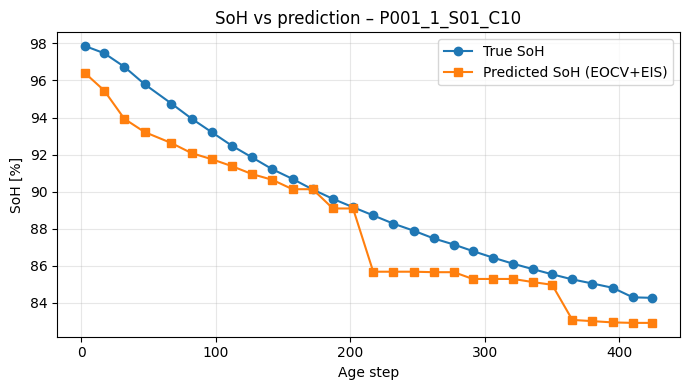

In [45]:
import matplotlib.pyplot as plt

# pick one test cell
test_cell = test_df["cell_id"].unique()[0]
mask = test_df["cell_id"] == test_cell

plt.figure(figsize=(7, 4))
plt.plot(
    test_df.loc[mask, "age_step"],
    y_test[mask],
    "o-",
    label="True SoH",
)
plt.plot(
    test_df.loc[mask, "age_step"],
    y_pred_eis[mask],
    "s-",
    label="Predicted SoH (EOCV+EIS)",
)
plt.xlabel("Age step")
plt.ylabel("SoH [%]")
plt.title(f"SoH vs prediction – {test_cell}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

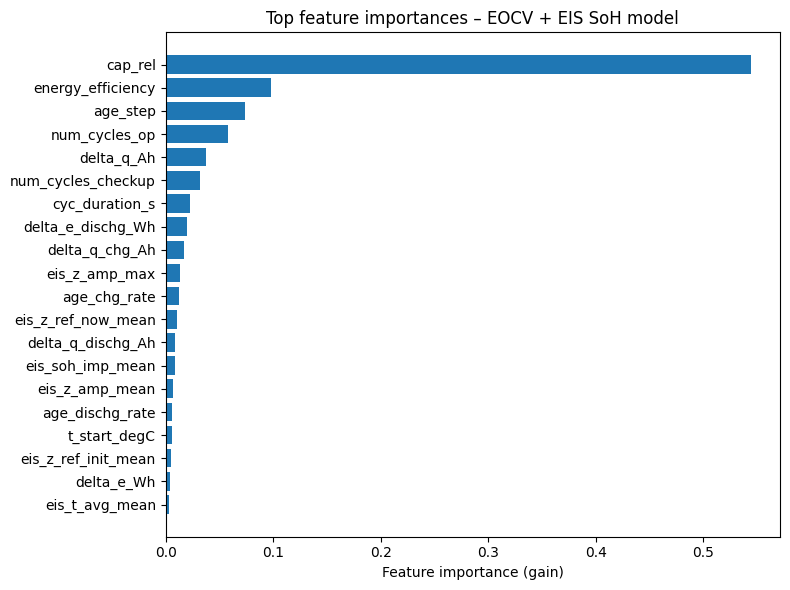

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# get feature importances from XGBoost model
importances = model_eis.feature_importances_
indices = np.argsort(importances)[::-1]  # sort descending

# choose top N features to display
N = 20
top_idx = indices[:N]
top_features = [feature_cols_all[i] for i in top_idx]
top_importances = importances[top_idx]

plt.figure(figsize=(8, 6))
plt.barh(range(len(top_features)), top_importances[::-1])
plt.yticks(range(len(top_features)), top_features[::-1])
plt.xlabel("Feature importance (gain)")
plt.title("Top feature importances – EOCV + EIS SoH model")
plt.tight_layout()
plt.show()

In [47]:
from pathlib import Path
import pandas as pd

pls_dir = Path("data") / "raw" / "results" / "cell_plsv2"

def load_all_pls(pls_dir: Path) -> pd.DataFrame:
    """
    Load all PLS (pulse) result CSVs and add a cell_id column.
    Each file contains pulse-test results for one cell / block.
    """
    csv_files = sorted(pls_dir.glob("cell_plsv2_*.csv"))
    dfs = []
    for f in csv_files:
        df = pd.read_csv(f, sep=";")
        cell_id = f.stem.replace("cell_plsv2_", "")
        df["cell_id"] = cell_id
        dfs.append(df)
    big_df = pd.concat(dfs, ignore_index=True)
    return big_df


pls_raw = load_all_pls(pls_dir)
pls_raw.head(), pls_raw["cell_id"].nunique(), pls_raw.shape

(    timestamp_s  timestamp_origin  sd_block_id  cyc_charged  is_rt  soc_nom  \
 0  1.665660e+09                 1     84402176            1      1       10   
 1  1.665660e+09                 1     84402176            1      1       10   
 2  1.665660e+09                 1     84402176            1      1       10   
 3  1.665660e+09                 1     84402176            1      1       10   
 4  1.665660e+09                 1     84402176            1      1       10   
 
    age_type  age_temp  age_soc  age_chg_rate  age_dischg_rate  age_profile  \
 0         1         0       10           0.0              0.0            0   
 1         1         0       10           0.0              0.0            0   
 2         1         0       10           0.0              0.0            0   
 3         1         0       10           0.0              0.0            0   
 4         1         0       10           0.0              0.0            0   
 
    t_avg_degC  r_ref_10ms_mOhm  r_ref_1s_

In [48]:
def build_pls_cell_features(pls_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate pulse-test data per cell into a few resistance-related features.
    """
    df = pls_df.copy()

    # Try to identify key numeric columns – adjust names if needed
    # You can inspect pls_raw.columns.tolist() and edit this list accordingly.
    candidate_cols = [c for c in df.columns if "res" in c.lower() or "r_" in c.lower()]
    # fall back to all numeric if needed
    if not candidate_cols:
        candidate_cols = df.select_dtypes(include=["number"]).columns.tolist()

    for col in candidate_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    rows = []
    for cell_id, g in df.groupby("cell_id"):
        # simple resistance statistics over all pulses
        res_means = {f"pls_{col}_mean": g[col].mean() for col in candidate_cols}
        res_maxs = {f"pls_{col}_max": g[col].max() for col in candidate_cols}
        res_mins = {f"pls_{col}_min": g[col].min() for col in candidate_cols}

        row = {"cell_id": cell_id}
        row.update(res_means)
        row.update(res_maxs)
        row.update(res_mins)
        rows.append(row)

    pls_cell = pd.DataFrame(rows)
    return pls_cell


pls_cell = build_pls_cell_features(pls_raw)
pls_cell.head(), pls_cell.shape

(          cell_id  pls_r_ref_10ms_mOhm_mean  pls_r_ref_1s_mOhm_mean  \
 0  P001_1_S01_C10                 24.313776               29.306666   
 1  P001_2_S04_C09                 24.499910               29.545721   
 2  P001_3_S05_C06                 24.571890               29.476154   
 3  P002_1_S02_C10                 24.794305               29.855884   
 4  P002_2_S03_C10                 24.927555               29.611610   
 
    pls_r_ref_10ms_mOhm_max  pls_r_ref_1s_mOhm_max  pls_r_ref_10ms_mOhm_min  \
 0                   34.063                 49.413                   17.113   
 1                   35.027                 50.548                   17.497   
 2                   36.276                 51.903                   16.649   
 3                   35.631                 52.090                   17.135   
 4                   36.238                 52.660                   17.005   
 
    pls_r_ref_1s_mOhm_min  
 0                 17.814  
 1                 18.138  
 2    

In [49]:
full_with_pls = full_model.merge(
    pls_cell,
    on="cell_id",
    how="left",
    suffixes=("", "_pls"),
)
full_with_pls.head(), full_with_pls.shape

(          cell_id sd_block_id  age_step   timestamp_s        soh cap_abs_Ah  \
 0  P001_1_S01_C10    75906048         3  1665626446.0  97.849625   2.967744   
 1  P001_1_S01_C10   229865472        17  1666232539.0  97.470522   2.962058   
 2  P001_1_S01_C10   692544000        32  1668031700.0  96.735221   2.951028   
 3  P001_1_S01_C10  1160319488        47  1669850919.0  95.799446   2.936992   
 4  P001_1_S01_C10  1625245184        67  1671659652.0  94.751292   2.921269   
 
     cap_rel     d_soh age_type  age_temp  ...  eis_t_avg_mean  eis_z_amp_mean  \
 0  0.998038 -0.388873        1         0  ...       13.320962       22.070084   
 1  0.996126 -1.282197        1         0  ...       13.320962       22.070084   
 2  0.992417 -1.109857        1         0  ...       13.320962       22.070084   
 3  0.987697 -1.149303        1         0  ...       13.320962       22.070084   
 4  0.982409 -1.063461        1         0  ...       13.320962       22.070084   
 
    eis_z_amp_min eis_z_

In [50]:
# Base and EIS features as before
base_cols = [
    "age_step",
    "age_temp",
    "age_soc",
    "age_chg_rate",
    "age_dischg_rate",
    "cyc_duration_s",
    "num_cycles_op",
    "num_cycles_checkup",
    "coulomb_efficiency",
    "energy_efficiency",
    "cap_rel",
    "d_soh",
    "soc_window",
    "t_start_degC",
    "t_end_degC",
    "temp_delta_degC",
    "delta_q_Ah",
    "delta_q_chg_Ah",
    "delta_q_dischg_Ah",
    "delta_e_Wh",
    "delta_e_chg_Wh",
    "delta_e_dischg_Wh",
]

eis_cols = [
    "eis_z_ref_init_mean",
    "eis_z_ref_now_mean",
    "eis_z_ref_now_last",
    "eis_soh_imp_mean",
    "eis_soh_imp_last",
    "eis_t_avg_mean",
    "eis_z_amp_mean",
    "eis_z_amp_min",
    "eis_z_amp_max",
]

# All PLS columns are those starting with "pls_"
pls_cols = [c for c in full_with_pls.columns if c.startswith("pls_")]

feature_cols_all = [c for c in base_cols + eis_cols + pls_cols if c in full_with_pls.columns]

# ensure numeric
for col in feature_cols_all:
    full_with_pls[col] = pd.to_numeric(full_with_pls[col], errors="coerce")

full_pls_model = full_with_pls.dropna(subset=feature_cols_all + ["soh"])
full_pls_model.shape

(523466, 46)

In [51]:
cell_ids = full_pls_model["cell_id"].astype(str).to_numpy()
train_cells, test_cells = train_test_split(cell_ids, test_size=0.2, random_state=42)

train_df = full_pls_model[full_pls_model["cell_id"].isin(train_cells)]
test_df = full_pls_model[full_pls_model["cell_id"].isin(test_cells)]

X_train = train_df[feature_cols_all]
y_train = train_df["soh"]

X_test = test_df[feature_cols_all]
y_test = test_df["soh"]

model_eis_pls = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model_eis_pls.fit(X_train, y_train)

y_pred_eis_pls = model_eis_pls.predict(X_test)

mae_eis_pls = mean_absolute_error(y_test, y_pred_eis_pls)
mse_eis_pls = mean_squared_error(y_test, y_pred_eis_pls)
rmse_eis_pls = np.sqrt(mse_eis_pls)

mae_eis_pls, rmse_eis_pls

(0.25843411684036255, np.float64(0.36740154764122523))

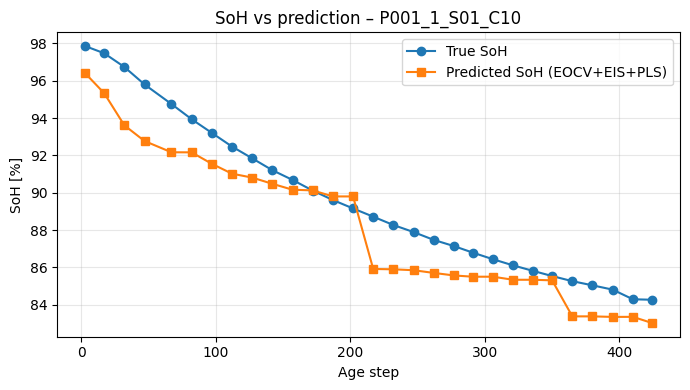

In [52]:
import matplotlib.pyplot as plt

# pick one test cell
test_cell = test_df["cell_id"].unique()[0]
mask = test_df["cell_id"] == test_cell

plt.figure(figsize=(7, 4))
plt.plot(
    test_df.loc[mask, "age_step"],
    y_test[mask],
    "o-",
    label="True SoH",
)
plt.plot(
    test_df.loc[mask, "age_step"],
    y_pred_eis_pls[mask],
    "s-",
    label="Predicted SoH (EOCV+EIS+PLS)",
)
plt.xlabel("Age step")
plt.ylabel("SoH [%]")
plt.title(f"SoH vs prediction – {test_cell}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
def build_early_life_dataset(full_df: pd.DataFrame, feature_cols, frac: float):
    """
    For each cell, take features at the last age_step within the early-life fraction (e.g. 0.2),
    and use final SoH as the target.
    Returns X, y, cell_ids.
    """
    rows = []

    for cell_id, g in full_df.groupby("cell_id"):
        g = g.sort_values("age_step")

        max_step = g["age_step"].max()
        cutoff = int(max_step * frac)

        # rows up to cutoff (early life)
        early = g[g["age_step"] <= cutoff]
        if early.empty:
            continue

        # use the last early row as the representation
        early_row = early.iloc[-1]

        # final SoH (target)
        final_soh = g["soh"].iloc[-1]

        row = early_row[feature_cols].to_dict()
        row["cell_id"] = cell_id
        row["target_final_soh"] = final_soh
        row["max_age_step"] = max_step
        row["early_age_step"] = early_row["age_step"]
        rows.append(row)

    early_df = pd.DataFrame(rows)

    # ensure numeric for features and target
    for col in feature_cols:
        early_df[col] = pd.to_numeric(early_df[col], errors="coerce")
    early_df["target_final_soh"] = pd.to_numeric(early_df["target_final_soh"], errors="coerce")

    early_df = early_df.dropna(subset=feature_cols + ["target_final_soh"])

    X = early_df[feature_cols]
    y = early_df["target_final_soh"]
    cell_ids = early_df["cell_id"].astype(str).to_numpy()

    return X, y, cell_ids, early_df

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import numpy as np

def eval_early_life(full_df, feature_cols, frac):
    X, y, cell_ids, early_df = build_early_life_dataset(full_df, feature_cols, frac)

    train_cells, test_cells = train_test_split(
        cell_ids, test_size=0.2, random_state=42
    )

    train_mask = early_df["cell_id"].isin(train_cells)
    test_mask = early_df["cell_id"].isin(test_cells)

    X_train = X[train_mask]
    y_train = y[train_mask]
    X_test = X[test_mask]
    y_test = y[test_mask]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    return mae, rmse, model, (X_test, y_test, y_pred, test_cells)

In [55]:
fractions = [0.1, 0.2, 0.3]
results = {}

for frac in fractions:
    mae, rmse, model, _ = eval_early_life(full_pls_model, feature_cols_all, frac)
    results[frac] = (mae, rmse)
    print(f"Early fraction {frac*100:.0f}%: MAE={mae:.3f}, RMSE={rmse:.3f}")

Early fraction 10%: MAE=5.942, RMSE=8.028
Early fraction 20%: MAE=6.762, RMSE=8.693
Early fraction 30%: MAE=6.783, RMSE=8.469


In [57]:
from pathlib import Path

logs_dir = Path("data") / "raw"/"results"
list(logs_dir.iterdir())

[WindowsPath('data/raw/results/cell_eisv2'),
 WindowsPath('data/raw/results/cell_eocv2'),
 WindowsPath('data/raw/results/cell_plsv2')]